In [34]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from prophet import Prophet

file_path = r"C:/Users/Dalbir/Downloads/Trends-Forecasting-Analytics-MLOps-Vertex-AI/data/processed_file/sales_featured.parquet"
df = pd.read_parquet(file_path)

monthly_sales = df.groupby(pd.Grouper(key='order_date', freq='ME'))['sales'].sum().reset_index()
monthly_sales = monthly_sales.set_index('order_date')
y = monthly_sales['sales']

In [ ]:
model = ARIMA(y, order=(3,1,1))
results = model.fit()
forecast = results.get_forecast(steps=6)
forecast_df = forecast.summary_frame()
monthly_sales['arima_forecast'] = results.predict(start=1, end=len(y), dynamic=False)

c:\Users\Dalbir\Downloads\Trends-Forecasting-Analytics-MLOps-Vertex-AI\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Dalbir\Downloads\Trends-Forecasting-Analytics-MLOps-Vertex-AI\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Dalbir\Downloads\Trends-Forecasting-Analytics-MLOps-Vertex-AI\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Dalbir\Downloads\Trends-Forecasting-Analytics-MLOps-Vertex-AI\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as startin

In [41]:
forecast_df

sales,mean,mean_se,mean_ci_lower,mean_ci_upper
2020-02-29,2.151687e+06,9.189519e+05,3.505746e+05,3.952800e+06
2020-03-31,3.454870e+05,9.392001e+05,-1.495311e+06,2.186285e+06
2020-04-30,3.851271e+06,9.911363e+05,1.908679e+06,5.793862e+06
2020-05-31,2.411229e+06,1.095611e+06,2.638707e+05,4.558587e+06
2020-06-30,4.332370e+06,1.096032e+06,2.184187e+06,6.480553e+06
2020-07-31,1.787484e+06,1.131553e+06,-4.303184e+05,4.005287e+06


In [40]:
monthly_sales

,sales,arima_forecast
order_date,,
2019-01-31,1812742.87,NaN
2019-02-28,2200078.08,6.047810e+05
2019-03-31,2804973.35,2.586874e+06
2019-04-30,3389217.98,1.615796e+06
2019-05-31,3150616.23,2.221955e+06
2019-06-30,2576280.15,2.150818e+06
2019-07-31,2646461.32,1.685448e+06
2019-08-31,2241083.37,1.890928e+06
2019-09-30,2094465.69,2.305911e+06


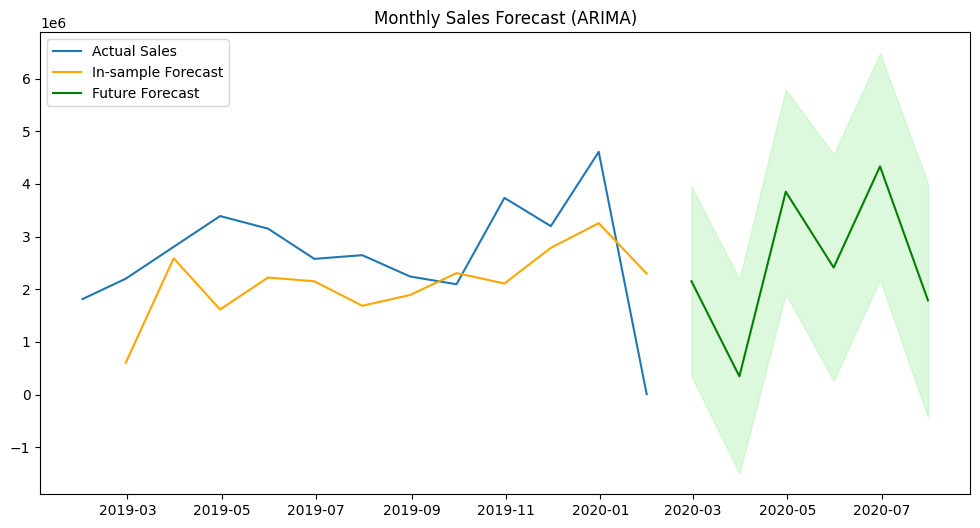

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y, label="Actual Sales")
plt.plot(monthly_sales['arima_forecast'], label="In-sample Forecast", color="orange")
plt.plot(forecast_df.index, forecast_df['mean'], label="Future Forecast", color="green")
plt.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'], color="lightgreen", alpha=0.3)
plt.title("Monthly Sales Forecast (ARIMA)")
plt.legend()
plt.show()

In [ ]:
prophet_df = monthly_sales.reset_index()[['order_date', 'sales']].rename(columns={'order_date': 'ds', 'sales': 'y'})


17:38:35 - cmdstanpy - INFO - Chain [1] start processing
17:38:37 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Dalbir\Downloads\Trends-Forecasting-Analytics-MLOps-Vertex-AI\venv\Lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [ ]:
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(prophet_df)
future = model.make_future_dataframe(periods=6, freq='M')
forecast = model.predict(future)

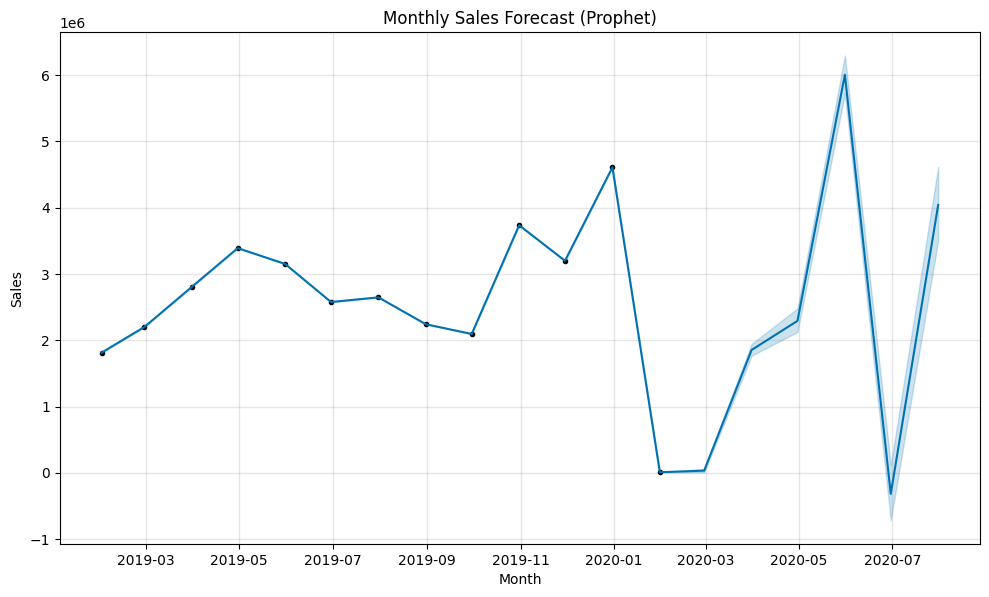

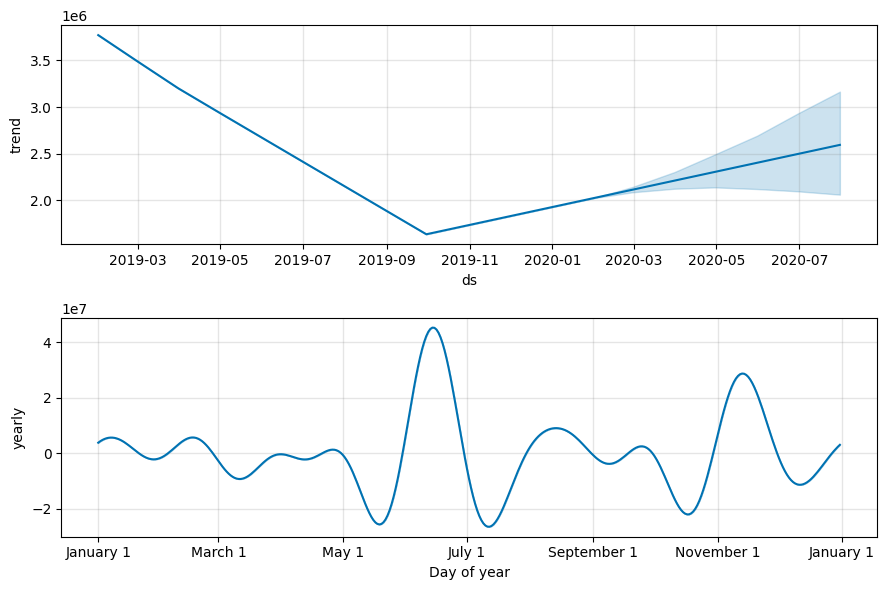

In [38]:
model.plot(forecast)
plt.title("Monthly Sales Forecast (Prophet)")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

model.plot_components(forecast)
plt.show()